<a href="https://cognitiveclass.ai"><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DL0101EN-SkillsNetwork/images/IDSN-logo.png" width="400"> </a>

# BackPropagation

Estimated time needed: **30** mins


Geri yayılım, sinir ağlarının verilerden öğrenmesini sağlayan, sinir ağlarını eğitmek için kullanılan temel algoritmadır. Gradyan iniş optimizasyon tekniğine dayanır ve tahmin edilen ve gerçek çıktılar arasındaki hatayı en aza indirmek için ağın ağırlıklarını ve sapmalarını yinelemeli olarak ayarlayarak çalışır.
Bu laboratuvar çalışmasında, bir XOR problemi için geri yayılımı uygulayacak bir sinir ağı oluşturacağız.

# Bu not defterinin amacı

* XOR problemini çözmek için bir sinir ağı eğitmek
* Sinir ağı eğitimi için geri yayılım algoritmasını uygulamak
* Aktivasyon fonksiyonlarının kullanımını göstermek
* Birden fazla epoch boyunca öğrenme sürecini anlamak
* Gradyan inişi yoluyla ağırlık ve sapma ayarlamalarını göstermek
* Eğitimden sonra modelin performansını değerlendirmek
* Eğitim sürecini izlemek ve analiz etmek

<h2>Table of Contents</h2>


<div class="alert alert-block alert-info" style="margin-top: 20px">

<font size = 4>
1. <a href="#Import-Required-Libraries">Gerekli Kütüphaneleri İçe Aktar</a><br>
2. <a href="#Initialize-Inputs">Girişleri Başlat</a><br>
3. <a href="#Declare-the-network-parameters">Ağ parametrelerini tanımla</a><br>
4. <a href="#Define-the-weights">Ağırlıkları tanımla</a><br>
5. <a href="#Training-the-Neural-Network">Sinir Ağını Eğit</a><br>
6. <a href="#Testing-the-Network">Ağı Test Et</a><br>
7. <a href="#Plot-the-error">Hata grafiğini çiz</a><br>
</font>
</div>


## Import Required Libraries


In [1]:
# Importing the required library
import numpy as np
import matplotlib.pyplot as plt

## Initialize Inputs
Define the input and expected output for a XOR gate problem


In [2]:
# Girişleri ve beklenen çıktıyı tanımlama (XOR doğruluk tablosu)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).T # 2x4 matris, her sütun bir eğitim örneğidir
d = np.array([0, 1, 1, 0]) # XOR için beklenen çıktı

# Ağ parametrelerini ve ağırlıkları tanımlayın

Aşağıdaki gibi ağ parametrelerini tanımlayın:
1. Giriş nöron sayısı
2. Gizli katman nöron sayısı
3. Çıkış nöron sayısı
4. Öğrenme oranı
5. Epoch sayısı

Ayrıca, nöronlar için ağırlıkları tanımlayın. Başlangıç ​​ağırlıkları rastgele sayılar olarak alınır ve daha sonra `initialize_network_parameters()` fonksiyon parametresi içinde geri yayılım algoritması tarafından optimize edilir.

In [7]:
def initialize_network_parameters():

# Ağ parametreleri

    inputSize = 2 # Giriş nöron sayısı (x1, x2)
    hiddenSize = 2 # Gizli nöron sayısı
    outputSize = 1 # Çıkış nöron sayısı
    lr = 0.1 # Öğrenme oranı
    epochs = 180000 # Eğitim döngüsü sayısı

# Ağırlıkları ve sapmaları [-1, 1] aralığında rastgele başlatın
    w1 = np.random.rand(hiddenSize, inputSize) * 2 - 1 # Girişten gizli katmana ağırlıklar
    b1 = np.random.rand(hiddenSize, 1) * 2 - 1 # Gizli katman için sapma
    w2 = np.random.rand(outputSize, hiddenSize) * 2 - 1 # Gizli katmandan çıkış katmanına ağırlıklar
    b2 = np.random.rand(outputSize, 1) * 2 - 1 # Çıkış katmanı için önyargı

    return w1, b1, w2, b2, lr, epochs

## Sinir Ağının Eğitimi

Sinir ağı 5 aşamada çalışır:
1. İleri Geçiş
* Giriş **X**, ağırlıklar **w1** ile çarpılır ve ilk katmandan geçirilir, ardından sigmoid veya ReLU aktivasyon fonksiyonu uygulanır. Bu, gizli katman için çıktıyı verir.
* Gizli katmanın çıktısı daha sonra son çıktıyı hesaplamak için ikinci ağırlık kümesi **w2**'den geçirilir. Yine, son çıktı **a2**'yi üretmek için bir sigmoid aktivasyon fonksiyonu kullanılır.
2. Hata Hesaplama
* Hata, beklenen çıktı **(d)** ile gerçek çıktı **(a2)** arasındaki fark olarak hesaplanır.
3. Geri Geçiş
* **Çıkış Katmanı**: Sigmoid aktivasyon fonksiyonunun türevi hataya uygulanır ve çıkış katmanı **(da2)** için gradyan üretilir. Bu, çıkış katmanındaki ağırlıkların ne kadar ayarlanması gerektiğini hesaplamak için kullanılır.
* **Gizli Katman**: Hata daha sonra gizli katmana doğru geriye doğru yayılır. Gizli katmandaki gradyan **(da1)**, ağırlıkların transpozunun **(w2.T)** ve çıkış katmanından gelen gradyanın nokta çarpımı alınarak hesaplanır. Bu hatayı düzeltmek için aktivasyon fonksiyonunun (sigmoid veya ReLU) türevi kullanılır.
4. Ağırlık ve sapma güncellemeleri
* **Gradyanlar (dz1, dz2)** hesaplandıktan sonra, **ağırlıklar (w1, w2)** ve **sapmalar (b1, b2)**, **öğrenme oranı (lr)** ve **gradyanlar** kullanılarak güncellenir. Güncellemeler, hatayı en aza indirmek ve modelin tahminlerini iyileştirmek için yapılır.
5. Eğitim:
* Bu sürecin tamamı birçok yineleme **(epoch)** boyunca tekrarlanır. Her epoch sırasında, model hatayı azaltmak için ağırlıklarını ve sapmalarını ayarlar. Zamanla, ağ XOR fonksiyonunu yaklaşık olarak hesaplamayı öğrenir.
İleri Geçiş:

In [11]:
# Başlangıç ​​parametrelerini al
w1, b1, w2, b2, lr, epochs = initialize_network_parameters()

# Geri yayılım kullanarak ağı eğit
error_list = []
for epoch in range(epochs):
    # İleri geçiş

    z1 = np.dot(w1, X) + b1 # Gizli katman için ağırlıklı toplam  dot = vektör çarpımı yapar
    a1 = 1 / (1 + np.exp(-z1)) # Gizli katman için sigmoid aktivasyonu

    z2 = np.dot(w2, a1) + b2 # Çıkış katmanı için ağırlıklı toplam
    a2 = 1 / (1 + np.exp(-z2)) # Çıkış katmanı için sigmoid aktivasyonu exp = e üzeri x gibi düşün

    # Hata hesaplama ve geri yayılım
    error = d - a2 # Beklenen ve gerçek çıktı arasındaki fark
    da2 = error * (a2 * (1 - a2)) # Çıkış katmanı için türev
    dz2 = da2 # Çıkış katmanı için gradyan

    # Hatayı gizli katmana yay

    da1 = np.dot(w2.T, dz2) # Gizli katman için gradyan
    dz1 = da1 * (a1 * (1 - a1)) # Gizli katman için türev

    # Ağırlıkları ve sapmaları güncelle
    w2 += lr * np.dot(dz2, a1.T) # Gizli katmandan çıkış katmanına ağırlıkları güncelle
    b2 += lr * np.sum(dz2, axis=1, keepdims=True) # Çıkış katmanı için sapmayı güncelle

    w1 += lr * np.dot(dz1, X.T) # Giriş katmanından gizli katmana ağırlıkları güncelle
    b1 += lr * np.sum(dz1, axis=1, keepdims=True) # Gizli katman için sapmayı güncelle

    if (epoch+1)%10000 == 0:
        print("Epoch: %d, Ortalama hata: %0.05f"%(epoch, np.average(abs(error))))
        error_list.append(np.average(abs(error)))

Epoch: 9999, Ortalama hata: 0.08585
Epoch: 19999, Ortalama hata: 0.03538
Epoch: 29999, Ortalama hata: 0.02558
Epoch: 39999, Ortalama hata: 0.02093
Epoch: 49999, Ortalama hata: 0.01810
Epoch: 59999, Ortalama hata: 0.01616
Epoch: 69999, Ortalama hata: 0.01472
Epoch: 79999, Ortalama hata: 0.01360
Epoch: 89999, Ortalama hata: 0.01270
Epoch: 99999, Ortalama hata: 0.01196
Epoch: 109999, Ortalama hata: 0.01132
Epoch: 119999, Ortalama hata: 0.01078
Epoch: 129999, Ortalama hata: 0.01031
Epoch: 139999, Ortalama hata: 0.00989
Epoch: 149999, Ortalama hata: 0.00952
Epoch: 159999, Ortalama hata: 0.00919
Epoch: 169999, Ortalama hata: 0.00889
Epoch: 179999, Ortalama hata: 0.00862


## Ağı Test Etme
Eğitimden sonra, XOR fonksiyonunu öğrendiğini ve [0, 1, 1, 0]'a yakın doğru değerler ürettiğini doğrulamak için sinir ağını test edebilirsiniz.

In [12]:
# Eğitilmiş ağı test etme
z1 = np.dot(w1, X) + b1 # Gizli katman için ağırlıklı toplam
a1 = 1 / (1 + np.exp(-z1)) # Gizli katman için sigmoid aktivasyon fonksiyonu

z2 = np.dot(w2, a1) + b2 # Çıkış katmanı için ağırlıklı toplam
a2 = 1 / (1 + np.exp(-z2)) # Çıkış katmanı için sigmoid aktivasyon fonksiyonu

# Sonuçları yazdırma
print('Eğitim sonrası nihai çıktı:', a2)
print('Gerçek değer', d)
print('Eğitim sonrası hata:', error)
print('Ortalama hata: %0.05f'%np.average(abs(error)))

Eğitim sonrası nihai çıktı: [[0.00796502 0.99178403 0.99178298 0.01006557]]
Gerçek değer [0 1 1 0]
Eğitim sonrası hata: [[-0.00796504  0.008216    0.00821704 -0.0100656 ]]
Ortalama hata: 0.00862


## Plot the error
Here, we plot the error as a function of epochs. This shows how error changed over multiple iterations of forward and backward passes and how the network learnt over time


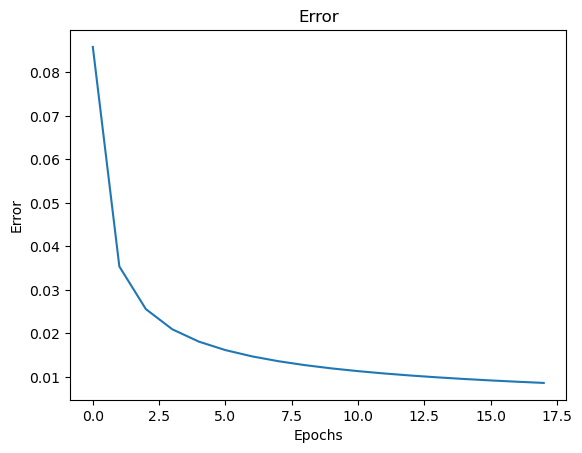

In [ ]:
# Plot error
plt.plot(error_list)
plt.title('Error')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.show()

# Practice exercise 1


Yukarıdaki XOR problemi için kullanılan girdiye benzer bir girdi kullanarak **VE problemi** için geri yayılım algoritmasını uygulayın ve hatayı grafiğe dökün.

Epoch: 9999, Average error: 0.02204
Epoch: 19999, Average error: 0.01408
Epoch: 29999, Average error: 0.01102
Epoch: 39999, Average error: 0.00931
Epoch: 49999, Average error: 0.00819
Epoch: 59999, Average error: 0.00738
Epoch: 69999, Average error: 0.00676
Epoch: 79999, Average error: 0.00627
Epoch: 89999, Average error: 0.00588
Epoch: 99999, Average error: 0.00554
Epoch: 109999, Average error: 0.00526
Epoch: 119999, Average error: 0.00501
Epoch: 129999, Average error: 0.00480
Epoch: 139999, Average error: 0.00461
Epoch: 149999, Average error: 0.00443
Epoch: 159999, Average error: 0.00428
Epoch: 169999, Average error: 0.00414
Epoch: 179999, Average error: 0.00402

Final output after training: [[2.05786897e-04 4.56390697e-03 4.59156858e-03 9.93299898e-01]]
Ground truth [0 0 0 1]
Error after training: [[-0.00020579 -0.00456392 -0.00459158  0.00670012]]
Average error: 0.00402


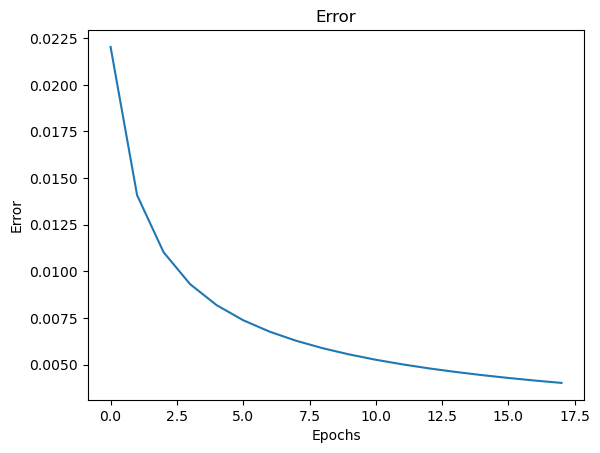

In [21]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).T  # 2x4 matrix, each column is a training example
d = np.array([0, 0, 0, 1])  # Expected output for AND

# Get initialized parameters
w1, b1, w2, b2, lr, epochs = initialize_network_parameters()

# Training the network using backpropagation
error_list = []
for epoch in range(epochs):
    # Forward pass
    z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
    a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

    z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
    a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

    # Error calculation and backpropagation
    error = d - a2  # Difference between expected and actual output
    da2 = error * (a2 * (1 - a2))  # Derivative for output layer
    dz2 = da2  # Gradient for output layer

    # Propagate error to hidden layer
    da1 = np.dot(w2.T, dz2)  # Gradient for hidden layer
    dz1 = da1 * (a1 * (1 - a1))  # Derivative for hidden layer

    # Update weights and biases
    w2 += lr * np.dot(dz2, a1.T)  # Update weights from hidden to output layer
    b2 += lr * np.sum(dz2, axis=1, keepdims=True)  # Update bias for output layer

    w1 += lr * np.dot(dz1, X.T)  # Update weights from input to hidden layer
    b1 += lr * np.sum(dz1, axis=1, keepdims=True)  # Update bias for hidden layer
    if (epoch+1)%10000 == 0:
        print("Epoch: %d, Average error: %0.05f"%(epoch, np.average(abs(error))))
        error_list.append(np.average(abs(error)))


# Testing the trained network
z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

# Print results
print('\nFinal output after training:', a2)
print('Ground truth', d)
print('Error after training:', error)
print('Average error: %0.05f'%np.average(abs(error)))

# Plot error
plt.plot(error_list)
plt.title('Error')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.show()


Double-click <b>here</b> for the solution.


<!-- Your answer is below:


X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).T  # 2x4 matrix, each column is a training example
d = np.array([0, 0, 0, 1])  # Expected output for AND

# Get initialized parameters
w1, b1, w2, b2, lr, epochs = initialize_network_parameters()

# Training the network using backpropagation
error_list = []
for epoch in range(epochs):
    # Forward pass
    z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
    a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

    z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
    a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

    # Error calculation and backpropagation
    error = d - a2  # Difference between expected and actual output
    da2 = error * (a2 * (1 - a2))  # Derivative for output layer
    dz2 = da2  # Gradient for output layer

    # Propagate error to hidden layer
    da1 = np.dot(w2.T, dz2)  # Gradient for hidden layer
    dz1 = da1 * (a1 * (1 - a1))  # Derivative for hidden layer

    # Update weights and biases
    w2 += lr * np.dot(dz2, a1.T)  # Update weights from hidden to output layer
    b2 += lr * np.sum(dz2, axis=1, keepdims=True)  # Update bias for output layer

    w1 += lr * np.dot(dz1, X.T)  # Update weights from input to hidden layer
    b1 += lr * np.sum(dz1, axis=1, keepdims=True)  # Update bias for hidden layer
    if (epoch+1)%10000 == 0:
        print("Epoch: %d, Average error: %0.05f"%(epoch, np.average(abs(error))))
        error_list.append(np.average(abs(error)))


# Testing the trained network
z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

# Print results
print('\nFinal output after training:', a2)
print('Ground truth', d)
print('Error after training:', error)
print('Average error: %0.05f'%np.average(abs(error)))

# Plot error
plt.plot(error_list)
plt.title('Error')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.show()


-->


# Practice exercise 2


Şimdi, öğrenme oranını 0,01'e düşürün ve epoch sayısını 1.000.000'e çıkarın ve XOR kapısı için hatayı kontrol edin.

Epoch: 9999, Average error: 0.27781
Epoch: 19999, Average error: 0.26568
Epoch: 29999, Average error: 0.26174
Epoch: 39999, Average error: 0.25968
Epoch: 49999, Average error: 0.25839
Epoch: 59999, Average error: 0.25749
Epoch: 69999, Average error: 0.25681
Epoch: 79999, Average error: 0.25628
Epoch: 89999, Average error: 0.25586
Epoch: 99999, Average error: 0.25550
Epoch: 109999, Average error: 0.25520
Epoch: 119999, Average error: 0.25495
Epoch: 129999, Average error: 0.25472
Epoch: 139999, Average error: 0.25453
Epoch: 149999, Average error: 0.25435
Epoch: 159999, Average error: 0.25419
Epoch: 169999, Average error: 0.25405
Epoch: 179999, Average error: 0.25392

Final output after training: [[0.00684433 0.49991444 0.9914245  0.50017937]]
Ground truth [0 1 1 0]
Error after training: [[-0.00684435  0.50008557  0.00857552 -0.50017937]]
Average error: 0.25392


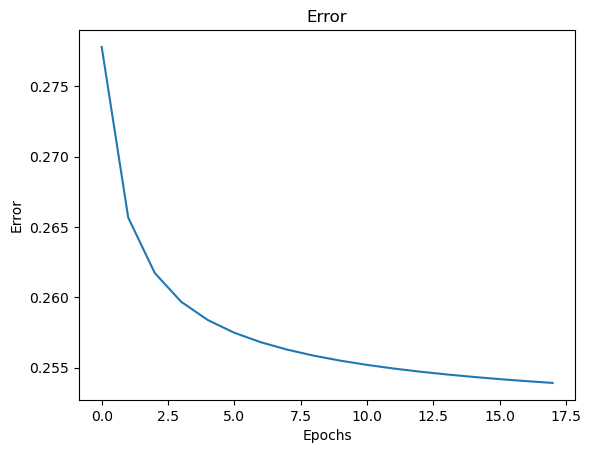

In [22]:
lr = 0.01         # Learning rate
epochs = 1000000   # Number of training epochs


# Defining inputs and expected output (XOR truth table)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).T  # 2x4 matrix, each column is a training example
d = np.array([0, 1, 1, 0])  # Expected output for XOR

# Get initialized parameters
w1, b1, w2, b2, lr, epochs = initialize_network_parameters()

# Training the network using backpropagation
error_list = []
for epoch in range(epochs):
    # Forward pass
    z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
    a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

    z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
    a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

    # Error calculation and backpropagation
    error = d - a2  # Difference between expected and actual output
    da2 = error * (a2 * (1 - a2))  # Derivative for output layer
    dz2 = da2  # Gradient for output layer

    # Propagate error to hidden layer
    da1 = np.dot(w2.T, dz2)  # Gradient for hidden layer
    dz1 = da1 * (a1 * (1 - a1))  # Derivative for hidden layer

    # Update weights and biases
    w2 += lr * np.dot(dz2, a1.T)  # Update weights from hidden to output layer
    b2 += lr * np.sum(dz2, axis=1, keepdims=True)  # Update bias for output layer

    w1 += lr * np.dot(dz1, X.T)  # Update weights from input to hidden layer
    b1 += lr * np.sum(dz1, axis=1, keepdims=True)  # Update bias for hidden layer
    if (epoch+1)%10000 == 0:
        print("Epoch: %d, Average error: %0.05f"%(epoch, np.average(abs(error))))
        error_list.append(np.average(abs(error)))


# Testing the trained network
z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

# Print results
print('\nFinal output after training:', a2)
print('Ground truth', d)
print('Error after training:', error)
print('Average error: %0.05f'%np.average(abs(error)))


# Plot error
plt.plot(error_list)
plt.title('Error')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.show()

Double-click <b>here</b> for the solution.

<!-- Your answer is below:

lr = 0.01         # Learning rate
epochs = 1000000   # Number of training epochs


# Defining inputs and expected output (XOR truth table)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).T  # 2x4 matrix, each column is a training example
d = np.array([0, 1, 1, 0])  # Expected output for XOR

# Get initialized parameters
w1, b1, w2, b2, lr, epochs = initialize_network_parameters()

# Training the network using backpropagation
error_list = []
for epoch in range(epochs):
    # Forward pass
    z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
    a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

    z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
    a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

    # Error calculation and backpropagation
    error = d - a2  # Difference between expected and actual output
    da2 = error * (a2 * (1 - a2))  # Derivative for output layer
    dz2 = da2  # Gradient for output layer

    # Propagate error to hidden layer
    da1 = np.dot(w2.T, dz2)  # Gradient for hidden layer
    dz1 = da1 * (a1 * (1 - a1))  # Derivative for hidden layer

    # Update weights and biases
    w2 += lr * np.dot(dz2, a1.T)  # Update weights from hidden to output layer
    b2 += lr * np.sum(dz2, axis=1, keepdims=True)  # Update bias for output layer

    w1 += lr * np.dot(dz1, X.T)  # Update weights from input to hidden layer
    b1 += lr * np.sum(dz1, axis=1, keepdims=True)  # Update bias for hidden layer
    if (epoch+1)%10000 == 0:
        print("Epoch: %d, Average error: %0.05f"%(epoch, np.average(abs(error))))
        error_list.append(np.average(abs(error)))


# Testing the trained network
z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

# Print results
print('\nFinal output after training:', a2)
print('Ground truth', d)
print('Error after training:', error)
print('Average error: %0.05f'%np.average(abs(error)))


# Plot error
plt.plot(error_list)
plt.title('Error')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.show()


-->


## Thank you for completing this lab!

This notebook was created by [Aman Aggarwal](https://www.linkedin.com/in/aggarwal-aman/). I hope you found this lab interesting and educational. Feel free to contact me if you have any questions!



<!--
## Change Log

|  Date (YYYY-MM-DD) |  Version | Changed By  |  Change Description |
|---|---|---|---|
| 2024-11-20  | 1.0  | Aman  |  Created the lab |
<hr>

## <h3 align="center"> © IBM Corporation. All rights reserved. <h3/>


## <h3 align="center"> &#169; IBM Corporation. All rights reserved. <h3/>
